In [17]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated, List

from langchain_huggingface import ChatHuggingFace, HuggingFacePipeline
import warnings

from langgraph.checkpoint.memory import MemorySaver # RAM memory

warnings.filterwarnings("ignore")
from pprint import pprint

In [3]:
# Local LLM to generate and optimize post
llm = HuggingFacePipeline.from_model_id(
        model_id="Qwen/Qwen2.5-3B-Instruct",
        task="text-generation",
        pipeline_kwargs={
            "temperature": 0.2,
            "return_full_text":False,
        },
    )

Loading weights: 100%|██████████| 434/434 [00:00<00:00, 5261.50it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [4]:
# state : use BaseMessage & add_messages when working with chatbots
class ChatState(TypedDict):
    messages : Annotated[List[BaseMessage], add_messages]

In [5]:
# chat node func
def chat_node(state: ChatState):

    chat_model = ChatHuggingFace(llm=llm)
    response = chat_model.invoke(state["messages"])

    return {"messages": [response]}

In [6]:
# graph
graph = StateGraph(ChatState)

# add node
graph.add_node("chat_node", chat_node)

# add edges
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

# compile
chatbot = graph.compile()

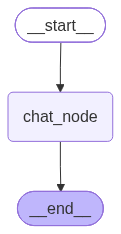

In [7]:
chatbot

# no follow up chatbot

In [17]:
initial_state = {"messages": ["I am jayesh"]}

response = chatbot.invoke(initial_state)

response

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'messages': [HumanMessage(content='I am jayesh', additional_kwargs={}, response_metadata={}, id='dd8f9553-d705-4e9b-9a59-1787aff77d15'),
  AIMessage(content='Hello Jayesh! How can I assist you today? Feel free to ask any questions or let me know if you need help with something specific.', additional_kwargs={}, response_metadata={}, id='lc_run--01a0131b-7cd8-7101-b478-02944aeb0e31-0', tool_calls=[], invalid_tool_calls=[])]}

# follow up chatbot but no memory [state refresh]

In [8]:
while True:
    msg = input("Q: ")
    print("User :", msg)
    if msg.strip().lower() in ["q"]:
        break

    response = chatbot.invoke({"messages": [msg]})
    print("AI :", response["messages"][-1].content)

User : Hi I am jayesh


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


AI : Hello Jayesh! It's nice to meet you. How can I assist you today? Do you have any specific questions or topics you'd like to discuss?
User : what is the capital of india


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


AI : The capital of India is New Delhi.
User : what is my name


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


AI : I'm sorry, but as an AI language model, I don't have access to information about your identity or personal details. My purpose is to assist with inquiries and provide information based on the data I've been trained on. If you'd like to discuss something specific, feel free to ask, and I'll do my best to help!
User : q


# follow up chatbot with short term memory

In [9]:
# checkpoint type
checkpointer = MemorySaver()

# graph
graph = StateGraph(ChatState)

# add node
graph.add_node("chat_node", chat_node)

# add edges
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

# compile
chatbot = graph.compile(checkpointer=checkpointer)

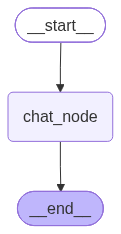

In [10]:
chatbot

In [11]:
while True:
    msg = input("Q: ")
    print("User :", msg)
    if msg.strip().lower() in ["q"]:
        break

    config = {'configurable': {"thread_id": "1"}} # store/load all conversation related to this thread

    response = chatbot.invoke(input={"messages": [msg]}, config=config)
    print("AI :", response["messages"][-1].content)

User : hi i am jayesh


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


AI : Hello Jayesh! It's nice to meet you. How can I assist you today? Do you have any specific questions or topics you'd like to discuss?
User : what is the captial of india


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


AI : The capital of India is New Delhi.
User : what is my name


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


AI : Your name is Jayesh, as you mentioned earlier. If you meant to ask about someone else, could you provide more context or information?
User : q


In [18]:
# load latest statesnapshot
pprint(chatbot.get_state(config=config).values)

{'messages': [HumanMessage(content='hi i am jayesh', additional_kwargs={}, response_metadata={}, id='9b4b9594-f5e5-4347-8340-5fe2a54b7f11'),
              AIMessage(content="Hello Jayesh! It's nice to meet you. How can I assist you today? Do you have any specific questions or topics you'd like to discuss?", additional_kwargs={}, response_metadata={}, id='lc_run--01a014f5-1686-7ba2-a346-bbfae5698a8a-0', tool_calls=[], invalid_tool_calls=[]),
              HumanMessage(content='what is the captial of india', additional_kwargs={}, response_metadata={}, id='b0a12ca3-86ef-4f74-8b31-17d188853c34'),
              AIMessage(content='The capital of India is New Delhi.', additional_kwargs={}, response_metadata={}, id='lc_run--01a014f5-4c84-73f1-be63-aa5aabad6d45-0', tool_calls=[], invalid_tool_calls=[]),
              HumanMessage(content='what is my name', additional_kwargs={}, response_metadata={}, id='9903b47e-3ea1-4102-b787-ce05b87a4913'),
              AIMessage(content='Your name is Jayesh

In [20]:
for snapshot in list(chatbot.get_state_history(config=config)):
    pprint(snapshot.values)
    print("-"*60)

{'messages': [HumanMessage(content='hi i am jayesh', additional_kwargs={}, response_metadata={}, id='9b4b9594-f5e5-4347-8340-5fe2a54b7f11'),
              AIMessage(content="Hello Jayesh! It's nice to meet you. How can I assist you today? Do you have any specific questions or topics you'd like to discuss?", additional_kwargs={}, response_metadata={}, id='lc_run--01a014f5-1686-7ba2-a346-bbfae5698a8a-0', tool_calls=[], invalid_tool_calls=[]),
              HumanMessage(content='what is the captial of india', additional_kwargs={}, response_metadata={}, id='b0a12ca3-86ef-4f74-8b31-17d188853c34'),
              AIMessage(content='The capital of India is New Delhi.', additional_kwargs={}, response_metadata={}, id='lc_run--01a014f5-4c84-73f1-be63-aa5aabad6d45-0', tool_calls=[], invalid_tool_calls=[]),
              HumanMessage(content='what is my name', additional_kwargs={}, response_metadata={}, id='9903b47e-3ea1-4102-b787-ce05b87a4913'),
              AIMessage(content='Your name is Jayesh